# Pythonを使ったセンサデータ解析
BME280という気温，湿度，気圧を計測できるセンサから得られた情報を解析してみよう！

---
## はじめに：jupyter notebookを使ってプログラムを書いてみよう！
jupyter notebookは，**セル**と呼ばれる枠の中にプログラムを記述し，実行します。<br>
下の空欄にprint('Hello Python')と入力し，**Run**ボタン(もしくはShift+Enter)を押しましょう。<br>
また，プログラムを入力するときは，キーボードを**半角**モードにしておきましょう。

In [ ]:
#ここが「セル」です。プログラムを書いてみよう！


プログラムは様々なデータについて計算をすることができます。以下のプログラムを記述し実行してみましょう。<br>
a = 11<br>
b = 29<br>
c = a + b<br>
print( c )

In [ ]:
#ここが「セル」です。プログラムを書いてみよう！


aやb，cは**変数**と呼ばれ，数値や文字，計算結果などを保存できます。<br>
変数はjupyter notebookを終了しない限り消えません。また，notebook内ではどこでも使うことができます。<br>
続けて次のプログラムを記述して実行してみましょう。三平方の定理を使って2辺$a,b$の長さより斜辺の長さ$c$を求めるプログラムです。<br>
なおプログラムでは，$a^2$は*(アスタリスク）を使って，a*aと書きます。<br>
$$ c=\sqrt{a^2+b^2} $$

import math<br>
a = 3<br>
b = 5<br>
c = math.sqrt(a\*a+b\*b)<br>
print( c )

In [ ]:
#ここが「セル」です。プログラムを書いてみよう！


**import math**は数学に関する**関数**がまとめられた道具箱(モジュールと呼びます）を呼び出すためのコードです。<br>
平方根の計算はmath.sqrt()と書いて，カッコの中に平方根の計算をしたい式や数値を書きます。<br>
また，sinやcos，ネピアの数$e$や円周率$\pi$なども使うことができます。<br>
pythonに限らず，様々なプログラム言語ではこれら関数を駆使して，複雑な計算をすることができます。

---
## 1.ThingSpeakからセンサデータを取得
ここからはThingSpeakにアクセスしてセンサデータを取得し，データを表示したり，実際に活用をしてみましょう。<br>
以下のセル内のプログラムを実行し，センサデータを取得するための**関数**を有効にします。

In [ ]:
import requests #webデータを操作するためのライブラリ
def getSenserData( num ):
    """
    ThingSpeakからデータを取得し，時刻，気圧，気温，湿度を返す関数
    """   
    timeLis = [] #時間
    presLis = [] #気圧
    tempLis = [] #温度
    humiLis = [] #湿度
    
    url = 'https://api.thingspeak.com/channels/1807461/feeds.json' #ThingSpeakにアクセスするためのアドレス
    para = {'timezone':'Asia/Tokyo','results':num}                 #タイムゾーン,要求データ数の設定
    response = requests.get( url, params = para )                  #データの要求
    
    if response.status_code == 200:        #データ取得ができた場合
        resList = response.json()['feeds'] #json形式に変換し'feeds'のみ取り出す
        if len(resList) > 1: #resListが1よりも大きい場合はlist形式で返す
            for elm in resList:
                timeLis.append( elm['created_at'][11:19] ) #時刻だけ取り出す
                presLis.append( float( elm['field1'] ) )   #気圧データ
                tempLis.append( float( elm['field2'] ) )   #温度データ
                humiLis.append( float( elm['field3'] ) )   #湿度データ   
            return timeLis, presLis, tempLis, humiLis
        else:
            time = resList[0]['created_at'][11:19]
            pres = float( resList[0]['field1'] )
            temp = float( resList[0]['field2'] )
            humi = float( resList[0]['field3'] )
            return time, pres, temp, humi
    else: #エラーの場合
        print( response )

以下のプログラムをセルに入力して，現在の時刻の環境データを表示してみましょう。<br>
time, pres, temp, humi = getSenserData(1)<br>
print( '現在の時刻：', time )<br>
print( '現在の気圧：', pres, 'hPa' )<br>
print( '現在の気温：', temp, '℃' )<br>
print( '現在の湿度：', humi, '%' )<br>

In [ ]:
#ここが「セル」です。プログラムを書いてみよう！


getSenserData()関数は，ThingSpeakサーバからセンサデータを取得する機能があります。<br>
カッコの中は取得したいデータの数を指定します。

---
## 2.センサデータの活用
それでは，センサデータを活用してみましょう。ここでは現在の気温と湿度から不快指数を計算してみます。<br>
また，計算した結果から不快度を言葉で表現するプログラムを作ってみましょう。<br>
日本における不快指数は以下の式で表現されます。<br>

不快指数 = 0.81 × 気温 + 0.01 × 湿度 ×（ 0.99 × 温度 - 14.3 ) + 46.3<br>

|不快指数　　|体感                        |
|:----------:|:--------------------------:|
|50未満      | 寒くてたまらない           |
|50以上55未満| 寒い                       |
|55以上60未満| 肌寒い                     |
|60以上65未満| 何も感じない               |
|65以上70未満| 快適                       |
|70以上75未満| 暑くない                   |
|75以上80未満| やや暑い                   |
|80以上85未満| 暑くて汗が出る             |
|85以上      | 暑くてたまらない           |

不快指数目安|オリオン機械株式会社,"https://www.orionkikai.co.jp/technology/pap/temperature-humidity/",閲覧日:2025/08/28


In [ ]:
#不快指数の式をプログラムしてみましょう。掛け算は＊（アスタリスク）記号を使います。
time, pres, temp, humi = getSenserData(1) #最新のセンサデータを取得
thi = 
print( '時間：', time, '気温：', temp, '[℃] 湿度：', humi, '[%] 不快指数：', thi )

#体感の判別
if thi < 50:
    print( '寒くてたまらない' )
elif thi < 55:
    print( '' ) #''の中に体感を表す言葉を記入してみよう
elif thi < 60:
    print( '' ) #''の中に体感を表す言葉を記入してみよう
elif thi < 65:
    print( '' ) #''の中に体感を表す言葉を記入してみよう
elif thi < 70:
    print( '' ) #''の中に体感を表す言葉を記入してみよう
elif thi < 75:
    print( '' ) #''の中に体感を表す言葉を記入してみよう
elif thi < 80:
    print( '' ) #''の中に体感を表す言葉を記入してみよう
elif thi < 85:
    print( '' ) #''の中に体感を表す言葉を記入してみよう
else:
    print( '' ) #''の中に体感を表す言葉を記入してみよう

if ・・・ elif ・・・を使うと，条件ごとにプログラムの内容を変えることができます。

さて，今まで触れてきたプログラミングの方法を応用して，1つ問題を考えてみましょう。<br>
今の時期はインフルエンザが流行する時期です。ウィルスの増殖が抑えられる最適な気温と湿度は<br>
「気温20度以上，湿度50～60%」と言われています。<br>
この教室はウィルスにとってどんな環境なのか，判定するプログラムを考えてみましょう。

In [ ]:
#ここが「セル」です。プログラムを書いてみよう！


---
## 3.センサデータをグラフに表示
30分間のセンサデータを取得し，そのデータをグラフ化することで，変化の様子を可視化してみましょう。<br>
15秒おきに計測しデータを送信しているので，30分間のデータ数は4データ×30分=120データになります。<br>
次のプログラムを実行し，データを取得してみましょう。

In [30]:
#120データを取得
timeLis, presLis, tempLis, humiLis = getSenserData(120)

リストは120個の変数をまとめて1つの変数として扱うことができます。<br>
以下のプログラムを実行して，リストへのアクセス方法を体感してみましょう。

In [31]:
#119番目のデータの確認
idx = 119
print( timeLis[idx], presLis[idx], tempLis[idx], humiLis[idx] )

21:40:16 1019.06 22.63 36.63672


最後に，30分のデータをグラフにしてみます。<br>
以下のプログラムを実行してみましょう。

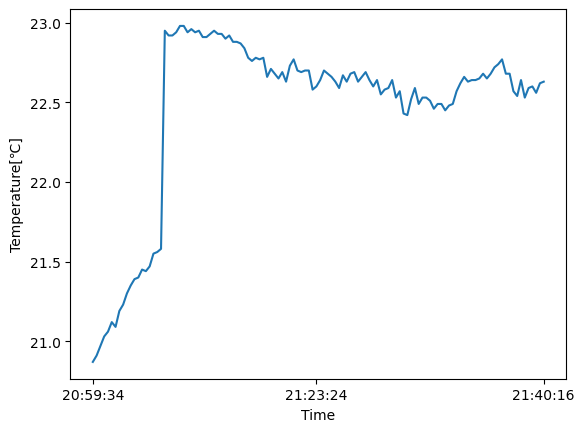

In [32]:
#グラフの表示
import matplotlib.pyplot as plt
plt.figure() #温度用のグラフを用意
plt.plot( timeLis, tempLis ) #グラフの表示
plt.xlabel( 'Time' ) #横軸のタイトル
plt.ylabel( 'Temperature[℃]' ) #縦軸のタイトル
plt.xticks( [0, 59, 119], [timeLis[0], timeLis[59], timeLis[119]] ) #横軸の目盛り
plt.show() #グラフの表示

上のプログラムを参考にして、気圧や湿度のグラフも表示してみましょう。

In [ ]:
#ここが「セル」です。プログラムを書いてみよう！
